In [1]:
import numpy as np
from PIL import Image

def fft_high_pass(img, cutoff=30, order=2):
    if img.ndim == 2:
        gray = img.astype(np.float32)
        chans = [gray]
        mode = "L"
    else:
        rgb = img.astype(np.float32)
        chans = [rgb[..., 0], rgb[..., 1], rgb[..., 2]]
        mode = "RGB"

    h, w = chans[0].shape
    yy, xx = np.mgrid[0:h, 0:w]
    cy, cx = h // 2, w // 2
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

    cutoff = float(cutoff)
    order = float(order)
    hp = 1.0 / (1.0 + (cutoff / (r + 1e-8)) ** (2.0 * order))

    out_chans = []
    for c in chans:
        F = np.fft.fftshift(np.fft.fft2(c))
        Ff = F * hp
        cf = np.fft.ifft2(np.fft.ifftshift(Ff))
        out_chans.append(np.real(cf))

    out = np.stack(out_chans, axis=-1) if mode == "RGB" else out_chans[0]
    return out

def normalize_to_uint8(x):
    x = np.asarray(x, dtype=np.float32)
    x -= x.min()
    m = x.max()
    if m > 0:
        x /= m
    x *= 255.0
    return x.clip(0, 255).astype(np.uint8)

In [2]:
from datasets import load_dataset

ds = load_dataset("weathon/minusface")

In [3]:
import os
val_paths = []
root = '/path/to/casia-webface'
with open("../../data_splits/index.txt","r") as f:
    lines = f.readlines()
    for line in lines:
        filename, split = line.strip().split()
        if split != "train":
            val_paths.append(os.path.join(root, filename)) 



In [4]:
import random
import tqdm
from deepface import DeepFace
import sys
sys.path.append("../../methods/fracface")

import data2npy
random.seed(42)
val_paths = random.sample(val_paths, k=30)

cache_templates = {}
for i in tqdm.tqdm(range(len(val_paths)), desc="Preloading cache_templates"):
    p = val_paths[i]
    img_s = DeepFace.extract_faces(p, detector_backend = "opencv", enforce_detection=False)[0]["face"]
    img_s = Image.fromarray((img_s * 255).astype("uint8")).resize((112,112))
    img_s = Image.open(p).convert("RGB")
    template = data2npy.preprocess_and_return(img_s, 1)[0]  
    cache_templates[p] = template


2026-01-18 20:50:23.147260: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-18 20:50:23.212727: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-18 20:50:24.863225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Preloading cache_templates: 100%|██████████| 30/30 [00:01<00:00, 19.70it/s]


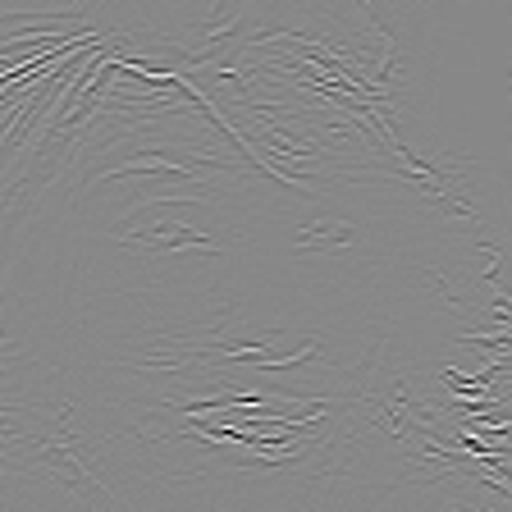

In [7]:
import numpy as np
import cv2
template = list(cache_templates.values())[16].mean(0, keepdim=True).repeat(3,1,1).permute(1,2,0).numpy()
template = (template - template.min()) / (template.max() - template.min()) * 255.0
template = normalize_to_uint8(template)
# in_path = "template.png"
in_path = "0001.png"
cutoff = 35
order = 1

# im = Image.open(in_path).convert("RGB")
# im = ds['train'][10]['image']
im = Image.fromarray(template)
arr = np.array(im)

hp = fft_high_pass(arr, cutoff=cutoff, order=order)

out = normalize_to_uint8(hp)

Image.fromarray(out).resize((512, 512))

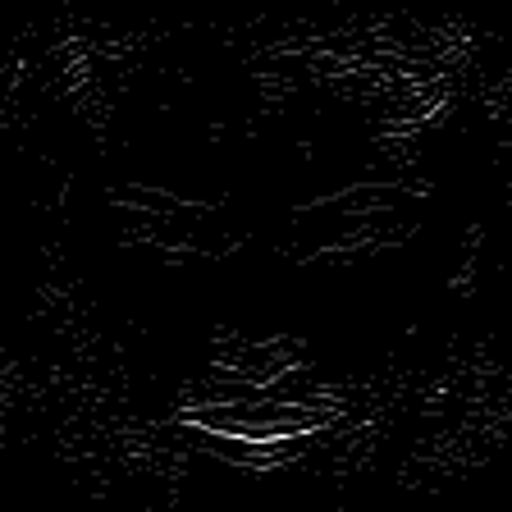

In [51]:
# gaussian high pass
# in_path = "template.png"
# in_path = "template.png"
in_path = "../../lora/fracfaece_student_templates/template_2.png"
r = 0.4
def gaussian_high_pass(img, sigma=3):
    blur = cv2.GaussianBlur(img, (0,0), sigma)
    hp = cv2.subtract(img, blur)
    return hp
    
# in_path = "0001.png"
# r = 0.33
im = Image.open(in_path).convert("L")

# im = ds['train'][10]['image']
# im = Image.fromarray(template) 

arr = np.array(im)
arr = Image.fromarray((arr * 255).astype("uint8")).resize((112,112)).convert("L").convert("RGB")
hp = gaussian_high_pass(np.array(arr), r)
hp = (hp - hp.min()) / (hp.max() - hp.min() + 1e-8) * 255.0 
out = normalize_to_uint8(hp)
Image.fromarray(out).resize((512, 512))